# 2024-11-17 Introduction to transiting exoplanets

## Explore this interactive

[Exoplanet simulation](Exoplanet_Sim.ipynb)


## Go to "Exoplanet System Simulation Interactive"

Answer these questions:

1. What does the *inclination* need to be to detect a transit?


1. How does change the *radius* of the planet affect the light curve? You cannot change the radius directly -- instead change the *mass* of the planet.
    
1. Why does the planet radius affect the light curve in that way?

    
1. How does moving the planet closer to the star change the light curve? Why does the light curve change that way?

1. Why isn't there a dip in the light curve when the planet goes behind the star?

## Now try this interactive plot

In [1]:
%matplotlib widget

import mpl_interactions.ipyplot as iplt
import matplotlib.pyplot as plt
import numpy as np
import batman


In [7]:
params = batman.TransitParams()

params.t0 = 0.                        #time of inferior conjunction
params.per = 1.                       #orbital period
params.rp = 0.1                       #planet radius (in units of stellar radii)
params.a = 15.                        #semi-major axis (in units of stellar radii)
params.inc = 87.                      #orbital inclination (in degrees)
params.ecc = 0.                       #eccentricity
params.w = 90.                        #longitude of periastron (in degrees)
params.limb_dark = "quadratic"        #limb darkening model
params.u = [0.1, 0.1]      #limb darkening coefficients [u1, u2, u3, u4]

t = np.linspace(-0.03, 0.03, 1000)  #times at which to calculate light curve
m = batman.TransitModel(params, t)    #initializes model

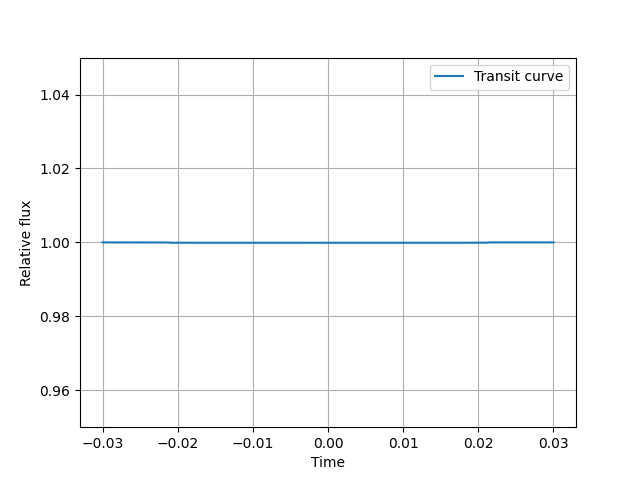

In [9]:
def f3(t, planet_radius, semi_major_axis):
    params.rp = planet_radius
    params.a = semi_major_axis
    return m.light_curve(params)


fig, ax = plt.subplots()
controls = iplt.plot(t, f3, planet_radius=np.linspace(0.01, 0.2, 20), semi_major_axis=np.linspace(7, 25, 100), label="Transit curve")
#iplt.plot(x, f2, controls=controls, label="f2")
_ = plt.legend()
plt.grid()
plt.ylim(0.95, 1.05)
plt.xlabel("Time")
plt.ylabel("Relative flux")
plt.show()